# LLM Assignment 3 — Task 1
## Multi-class Classification using Fully Connected Neural Networks


## 1. Imports and reproducibility


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

SEED = 42
rng = np.random.default_rng(SEED)

print("NumPy version:", np.__version__)
print("Random seed:", SEED)


NumPy version: 2.5.1
Random seed: 42


## 2. Dataset generation

### Dataset 1 — Three Gaussian clusters
Three compact, linearly separable 2-D Gaussian-like classes are generated with different means and covariance matrices.

### Dataset 2 — Three interleaving spiral arms
Three nonlinear spiral classes are generated in 2-D. The classes are deliberately interleaved so that a single linear decision boundary cannot separate them.


In [2]:
def generate_gaussian_dataset(n_per_class=500, seed=42):
    rng = np.random.default_rng(seed)

    means = np.array([
        [-2.6, -1.7],
        [ 2.7, -1.4],
        [ 0.0,  2.8]
    ])

    covariances = [
        np.array([[0.42, 0.05], [0.05, 0.30]]),
        np.array([[0.35, -0.04], [-0.04, 0.48]]),
        np.array([[0.38, 0.02], [0.02, 0.40]])
    ]

    X_parts, y_parts = [], []
    for c in range(3):
        Xc = rng.multivariate_normal(means[c], covariances[c], size=n_per_class)
        yc = np.full(n_per_class, c, dtype=int)
        X_parts.append(Xc)
        y_parts.append(yc)

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y


def generate_spiral_dataset(n_per_class=500, noise=0.10, seed=42):
    rng = np.random.default_rng(seed)

    X_parts, y_parts = [], []
    for c in range(3):
        r = np.linspace(0.15, 1.0, n_per_class)
        theta = np.linspace(0, 3.2 * np.pi, n_per_class) + c * (2*np.pi/3)

        # Small random perturbation makes the dataset less perfectly deterministic.
        theta = theta + rng.normal(0, noise, n_per_class)

        x = r * np.cos(theta)
        y = r * np.sin(theta)

        Xc = np.column_stack([x, y])
        X_parts.append(Xc)
        y_parts.append(np.full(n_per_class, c, dtype=int))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y


X_gauss, y_gauss = generate_gaussian_dataset(n_per_class=500, seed=SEED)
X_spiral, y_spiral = generate_spiral_dataset(n_per_class=500, noise=0.10, seed=SEED)

print("Gaussian:", X_gauss.shape, "classes:", np.bincount(y_gauss))
print("Spiral:  ", X_spiral.shape, "classes:", np.bincount(y_spiral))


Gaussian: (1500, 2) classes: [500 500 500]
Spiral:   (1500, 2) classes: [500 500 500]


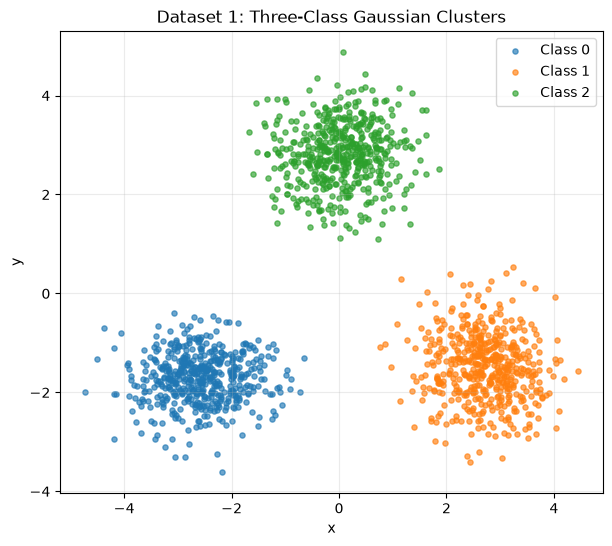

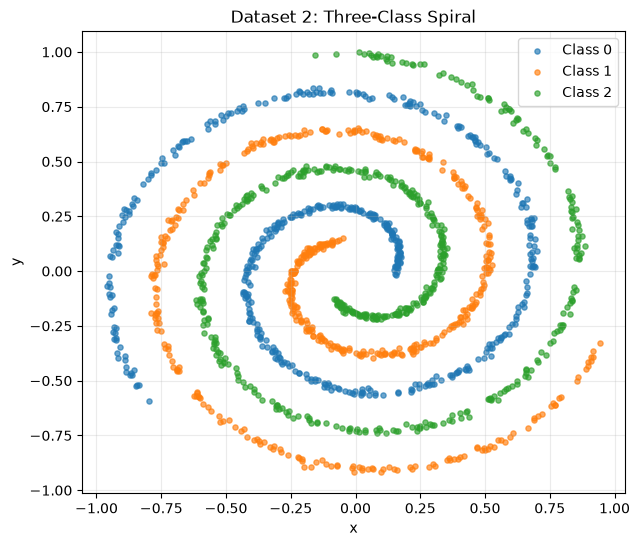

In [3]:
def plot_dataset(X, y, title):
    plt.figure(figsize=(7, 6))
    for c in np.unique(y):
        mask = y == c
        plt.scatter(X[mask, 0], X[mask, 1], s=14, alpha=0.65, label=f"Class {c}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

plot_dataset(X_gauss, y_gauss, "Dataset 1: Three-Class Gaussian Clusters")
plot_dataset(X_spiral, y_spiral, "Dataset 2: Three-Class Spiral")


## 3. Stratified 60/20/20 split

The splits are performed **from each class**, with:
- 60% training
- 20% validation
- 20% test

The function below performs that split independently for every class and then shuffles each final partition.


In [4]:
def stratified_split_60_20_20(X, y, seed=42):
    rng = np.random.default_rng(seed)

    train_idx, val_idx, test_idx = [], [], []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)

        n = len(idx)
        n_train = int(0.60 * n)
        n_val = int(0.20 * n)

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train+n_val])
        test_idx.extend(idx[n_train+n_val:])

    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)
    test_idx = np.array(test_idx)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return (
        X[train_idx], y[train_idx],
        X[val_idx], y[val_idx],
        X[test_idx], y[test_idx]
    )


g_train_X, g_train_y, g_val_X, g_val_y, g_test_X, g_test_y = stratified_split_60_20_20(
    X_gauss, y_gauss, seed=SEED
)

s_train_X, s_train_y, s_val_X, s_val_y, s_test_X, s_test_y = stratified_split_60_20_20(
    X_spiral, y_spiral, seed=SEED
)

def split_report(y_train, y_val, y_test, name):
    print(f"\n{name}")
    print("Train:", len(y_train), np.bincount(y_train))
    print("Val:  ", len(y_val),   np.bincount(y_val))
    print("Test: ", len(y_test),  np.bincount(y_test))

split_report(g_train_y, g_val_y, g_test_y, "Gaussian split")
split_report(s_train_y, s_val_y, s_test_y, "Spiral split")



Gaussian split
Train: 900 [300 300 300]
Val:   300 [100 100 100]
Test:  300 [100 100 100]

Spiral split
Train: 900 [300 300 300]
Val:   300 [100 100 100]
Test:  300 [100 100 100]


## 4. Standardization using training data only

Standardization improves numerical stability.  
The mean and standard deviation are computed **only from the training set** and then applied unchanged to validation/test data, preventing data leakage.


In [5]:
class StandardScalerFromScratch:
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ < 1e-12] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


g_scaler = StandardScalerFromScratch()
g_train = g_scaler.fit_transform(g_train_X)
g_val = g_scaler.transform(g_val_X)
g_test = g_scaler.transform(g_test_X)

s_scaler = StandardScalerFromScratch()
s_train = s_scaler.fit_transform(s_train_X)
s_val = s_scaler.transform(s_val_X)
s_test = s_scaler.transform(s_test_X)

def one_hot(y, n_classes=3):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y

g_train_Y = one_hot(g_train_y)
g_val_Y = one_hot(g_val_y)
g_test_Y = one_hot(g_test_y)

s_train_Y = one_hot(s_train_y)
s_val_Y = one_hot(s_val_y)
s_test_Y = one_hot(s_test_y)


## 5. FCNN implemented from scratch

### Activation

Sigmoid is used in hidden layers:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

with derivative:

$$
\sigma'(z)=\sigma(z)\left(1-\sigma(z)\right)
$$

The output layer also uses sigmoid activations so that each output node represents the corresponding one-hot class score.

### Instantaneous squared error

For one example:

$$
E=\frac{1}{2}\sum_k (t_k-o_k)^2
$$

The reported epoch error is the mean instantaneous squared error over all training examples.

### SGD

For every training example:

1. Forward propagation.
2. Compute squared-error loss.
3. Backpropagate the error.
4. Update weights immediately.


In [6]:
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative_from_activation(a):
    return a * (1.0 - a)


class FCNN:
    def __init__(self, input_dim, hidden_layers, output_dim=3, seed=42, learning_rate=0.03):
        self.architecture = [input_dim] + list(hidden_layers) + [output_dim]
        self.learning_rate = learning_rate
        self.rng = np.random.default_rng(seed)

        self.W = []
        self.b = []

        # Xavier-style initialization keeps activations in a useful range.
        for fan_in, fan_out in zip(self.architecture[:-1], self.architecture[1:]):
            limit = np.sqrt(6.0 / (fan_in + fan_out))
            self.W.append(self.rng.uniform(-limit, limit, size=(fan_in, fan_out)))
            self.b.append(np.zeros((1, fan_out)))

    def forward(self, x):
        activations = [x.reshape(1, -1)]
        pre_activations = []

        a = activations[0]

        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            pre_activations.append(z)
            a = sigmoid(z)
            activations.append(a)

        return activations, pre_activations

    def predict_scores(self, X):
        outputs = np.zeros((len(X), self.architecture[-1]))
        for i, x in enumerate(X):
            acts, _ = self.forward(x)
            outputs[i] = acts[-1].ravel()
        return outputs

    def predict(self, X):
        return np.argmax(self.predict_scores(X), axis=1)

    def sample_loss(self, target, output):
        return 0.5 * np.sum((target - output) ** 2)

    def train_one_epoch(self, X, Y, shuffle=True):
        indices = np.arange(len(X))
        if shuffle:
            self.rng.shuffle(indices)

        total_error = 0.0

        for idx in indices:
            x = X[idx]
            target = Y[idx]

            activations, pre_activations = self.forward(x)
            output = activations[-1]

            total_error += self.sample_loss(target.reshape(1, -1), output)

            # dE/do = o - t
            delta = (output - target.reshape(1, -1)) * sigmoid_derivative_from_activation(output)

            deltas = [None] * len(self.W)
            deltas[-1] = delta

            # Backpropagate through hidden layers.
            for layer in range(len(self.W) - 2, -1, -1):
                next_delta = deltas[layer + 1]
                delta = (next_delta @ self.W[layer + 1].T) * sigmoid_derivative_from_activation(activations[layer + 1])
                deltas[layer] = delta

            # SGD update.
            for layer in range(len(self.W)):
                self.W[layer] -= self.learning_rate * (activations[layer].T @ deltas[layer])
                self.b[layer] -= self.learning_rate * deltas[layer]

        return total_error / len(X)

    def fit(self, X, Y, epochs=1200, verbose_every=100):
        history = []

        for epoch in range(1, epochs + 1):
            avg_error = self.train_one_epoch(X, Y, shuffle=True)
            history.append(avg_error)

            if verbose_every and (epoch == 1 or epoch % verbose_every == 0):
                print(f"Epoch {epoch:4d} | average squared error = {avg_error:.6f}")

        return np.array(history)


## 6. Evaluation utilities



In [7]:
def confusion_matrix_manual(y_true, y_pred, n_classes=3):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[int(true), int(pred)] += 1
    return cm


def accuracy_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)


def evaluate_model(model, X, y):
    pred = model.predict(X)
    return accuracy_manual(y, pred), confusion_matrix_manual(y, pred)


def print_confusion_matrix(cm, title):
    print(title)
    display(pd.DataFrame(
        cm,
        index=[f"True {i}" for i in range(cm.shape[0])],
        columns=[f"Pred {i}" for i in range(cm.shape[1])]
    ))


# 7. Dataset 1 — Gaussian clusters

We compare several hidden-node counts and use validation accuracy to select the best architecture.


In [8]:
GAUSSIAN_ARCHITECTURES = [
    [2],
    [4],
    [8],
    [16],
    [32]
]

GAUSSIAN_EPOCHS = 1200
LEARNING_RATE = 0.03

gaussian_models = {}
gaussian_histories = []
gaussian_results = []

for hidden in GAUSSIAN_ARCHITECTURES:
    print(f"\nTraining Gaussian architecture: {hidden}")

    model = FCNN(
        input_dim=2,
        hidden_layers=hidden,
        output_dim=3,
        seed=SEED,
        learning_rate=LEARNING_RATE
    )

    history = model.fit(g_train, g_train_Y, epochs=GAUSSIAN_EPOCHS, verbose_every=300)

    train_acc, _ = evaluate_model(model, g_train, g_train_y)
    val_acc, val_cm = evaluate_model(model, g_val, g_val_y)

    gaussian_models[tuple(hidden)] = model
    gaussian_histories.append((hidden, history))
    gaussian_results.append({
        "Architecture": f"2-{hidden[0]}-3",
        "Hidden nodes": hidden[0],
        "Training accuracy": train_acc,
        "Validation accuracy": val_acc,
        "Final training error": history[-1]
    })

gaussian_results_df = pd.DataFrame(gaussian_results).sort_values(
    "Validation accuracy", ascending=False
).reset_index(drop=True)

display(gaussian_results_df)



Training Gaussian architecture: [2]
Epoch    1 | average squared error = 0.274543
Epoch  300 | average squared error = 0.001126
Epoch  600 | average squared error = 0.000559
Epoch  900 | average squared error = 0.000373
Epoch 1200 | average squared error = 0.000279

Training Gaussian architecture: [4]
Epoch    1 | average squared error = 0.285752
Epoch  300 | average squared error = 0.000361
Epoch  600 | average squared error = 0.000182
Epoch  900 | average squared error = 0.000122
Epoch 1200 | average squared error = 0.000092

Training Gaussian architecture: [8]
Epoch    1 | average squared error = 0.344529
Epoch  300 | average squared error = 0.000342
Epoch  600 | average squared error = 0.000181
Epoch  900 | average squared error = 0.000124
Epoch 1200 | average squared error = 0.000094

Training Gaussian architecture: [16]
Epoch    1 | average squared error = 0.260435
Epoch  300 | average squared error = 0.000312
Epoch  600 | average squared error = 0.000167
Epoch  900 | average sq

,Architecture,Hidden nodes,Training accuracy,Validation accuracy,Final training error
0,2-2-3,2,1.0,1.0,0.000279
1,2-4-3,4,1.0,1.0,0.000092
2,2-8-3,8,1.0,1.0,0.000094
3,2-16-3,16,1.0,1.0,0.000087
4,2-32-3,32,1.0,1.0,0.000106


In [9]:
print("Validation confusion matrices for all Gaussian architectures:")

for hidden, model in gaussian_models.items():
    val_acc, val_cm = evaluate_model(model, g_val, g_val_y)
    print(f"\nArchitecture: 2-{hidden[0]}-3 | Validation accuracy: {val_acc:.4f}")
    print(val_cm)


Validation confusion matrices for all Gaussian architectures:

Architecture: 2-2-3 | Validation accuracy: 1.0000
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]

Architecture: 2-4-3 | Validation accuracy: 1.0000
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]

Architecture: 2-8-3 | Validation accuracy: 1.0000
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]

Architecture: 2-16-3 | Validation accuracy: 1.0000
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]

Architecture: 2-32-3 | Validation accuracy: 1.0000
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]


In [10]:
best_gaussian_hidden = list(gaussian_results_df.iloc[0]["Hidden nodes"] if False else [int(gaussian_results_df.iloc[0]["Hidden nodes"])])
best_gaussian_key = tuple(best_gaussian_hidden)
best_gaussian_model = gaussian_models[best_gaussian_key]

best_gaussian_val_acc, best_gaussian_val_cm = evaluate_model(
    best_gaussian_model, g_val, g_val_y
)
best_gaussian_test_acc, best_gaussian_test_cm = evaluate_model(
    best_gaussian_model, g_test, g_test_y
)

print("Best Gaussian architecture:", f"2-{best_gaussian_hidden[0]}-3")
print(f"Validation accuracy: {best_gaussian_val_acc:.4f}")
print(f"Test accuracy:       {best_gaussian_test_acc:.4f}")
print()
print_confusion_matrix(best_gaussian_val_cm, "Gaussian validation confusion matrix")
print_confusion_matrix(best_gaussian_test_cm, "Gaussian test confusion matrix")


Best Gaussian architecture: 2-2-3
Validation accuracy: 1.0000
Test accuracy:       1.0000

Gaussian validation confusion matrix


,Pred 0,Pred 1,Pred 2
True 0,100,0,0
True 1,0,100,0
True 2,0,0,100


Gaussian test confusion matrix


,Pred 0,Pred 1,Pred 2
True 0,100,0,0
True 1,0,100,0
True 2,0,0,100


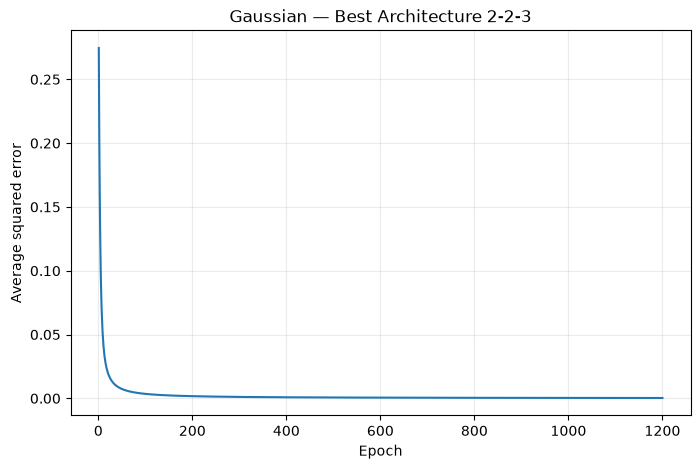

In [12]:
# Required: average error vs epochs ONLY for the selected best architecture.

best_gaussian_history = None

for hidden, history in gaussian_histories:
    if hidden == best_gaussian_hidden:
        best_gaussian_history = history
        break

plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(best_gaussian_history) + 1),
    best_gaussian_history
)

plt.xlabel("Epoch")
plt.ylabel("Average squared error")
plt.title(f"Gaussian — Best Architecture 2-{best_gaussian_hidden[0]}-3")
plt.grid(alpha=0.25)
plt.show()

## 8. Gaussian decision region

The decision region is generated by feeding a dense 2-D grid through the trained best FCNN. The training samples are superimposed as required.


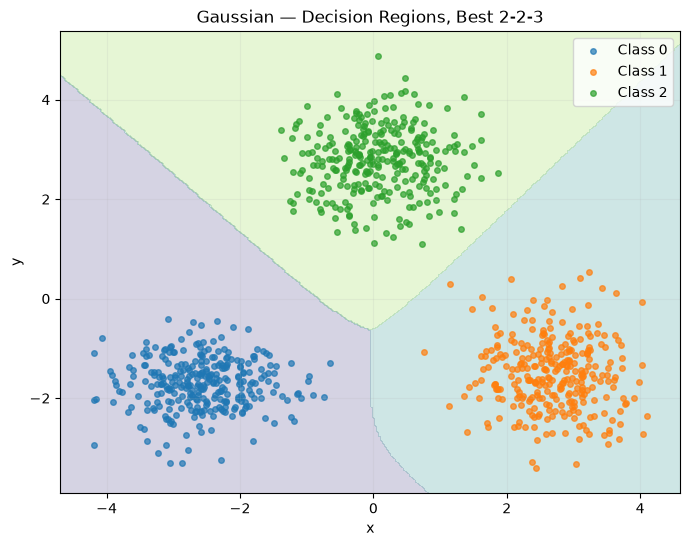

In [13]:
def plot_decision_regions(model, X_original, y, scaler, title, grid_points=300):
    x_min, x_max = X_original[:, 0].min() - 0.5, X_original[:, 0].max() + 0.5
    y_min, y_max = X_original[:, 1].min() - 0.5, X_original[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )

    grid_original = np.column_stack([xx.ravel(), yy.ravel()])
    grid_scaled = scaler.transform(grid_original)
    Z = model.predict(grid_scaled).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.22, levels=np.arange(-0.5, 3.5, 1))
    for c in np.unique(y):
        mask = y == c
        plt.scatter(
            X_original[mask, 0],
            X_original[mask, 1],
            s=16,
            alpha=0.7,
            label=f"Class {c}"
        )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.15)
    plt.show()


plot_decision_regions(
    best_gaussian_model,
    g_train_X,
    g_train_y,
    g_scaler,
    f"Gaussian — Decision Regions, Best 2-{best_gaussian_hidden[0]}-3"
)


# 9. Dataset 2 — Spiral
 
Several two-hidden-layer architectures are tested.


In [30]:
SPIRAL_ARCHITECTURES = [
    [4, 4],
    [8, 8],
    [16, 16]
]


SPIRAL_EPOCHS = 1800

spiral_models = {}
spiral_histories = []
spiral_results = []

for hidden in SPIRAL_ARCHITECTURES:
    print(f"\nTraining Spiral architecture: {hidden}")

    model = FCNN(
        input_dim=2,
        hidden_layers=hidden,
        output_dim=3,
        seed=SEED,
        learning_rate=LEARNING_RATE
    )

    history = model.fit(s_train, s_train_Y, epochs=SPIRAL_EPOCHS, verbose_every=450)

    train_acc, _ = evaluate_model(model, s_train, s_train_y)
    val_acc, val_cm = evaluate_model(model, s_val, s_val_y)

    spiral_models[tuple(hidden)] = model
    spiral_histories.append((hidden, history))
    spiral_results.append({
        "Architecture": f"2-{hidden[0]}-{hidden[1]}-3",
        "Hidden nodes layer 1": hidden[0],
        "Hidden nodes layer 2": hidden[1],
        "Training accuracy": train_acc,
        "Validation accuracy": val_acc,
        "Final training error": history[-1]
    })

spiral_results_df = pd.DataFrame(spiral_results).sort_values(
    "Validation accuracy", ascending=False
).reset_index(drop=True)

display(spiral_results_df)



Training Spiral architecture: [4, 4]
Epoch    1 | average squared error = 0.338753
Epoch  450 | average squared error = 0.310911
Epoch  900 | average squared error = 0.268195
Epoch 1350 | average squared error = 0.248894
Epoch 1800 | average squared error = 0.195217

Training Spiral architecture: [8, 8]
Epoch    1 | average squared error = 0.338728
Epoch  450 | average squared error = 0.304699
Epoch  900 | average squared error = 0.223560
Epoch 1350 | average squared error = 0.114264
Epoch 1800 | average squared error = 0.051334

Training Spiral architecture: [16, 16]
Epoch    1 | average squared error = 0.339109
Epoch  450 | average squared error = 0.303683
Epoch  900 | average squared error = 0.164604
Epoch 1350 | average squared error = 0.019567
Epoch 1800 | average squared error = 0.003957


,Architecture,Hidden nodes layer 1,Hidden nodes layer 2,Training accuracy,Validation accuracy,Final training error
0,2-16-16-3,16,16,1.000000,0.996667,0.003957
1,2-8-8-3,8,8,0.974444,0.960000,0.051334
2,2-4-4-3,4,4,0.740000,0.720000,0.195217


In [31]:
print("Validation confusion matrices for all Spiral architectures:")

for hidden, model in spiral_models.items():
    val_acc, val_cm = evaluate_model(model, s_val, s_val_y)
    print(f"\nArchitecture: 2-{hidden[0]}-{hidden[1]}-3 | Validation accuracy: {val_acc:.4f}")
    print(val_cm)


Validation confusion matrices for all Spiral architectures:

Architecture: 2-4-4-3 | Validation accuracy: 0.7200
[[58 18 24]
 [ 7 87  6]
 [ 7 22 71]]

Architecture: 2-8-8-3 | Validation accuracy: 0.9600
[[98  2  0]
 [ 2 93  5]
 [ 2  1 97]]

Architecture: 2-16-16-3 | Validation accuracy: 0.9967
[[ 99   0   1]
 [  0 100   0]
 [  0   0 100]]


In [32]:
best_spiral_row = spiral_results_df.iloc[0]
best_spiral_hidden = [
    int(best_spiral_row["Hidden nodes layer 1"]),
    int(best_spiral_row["Hidden nodes layer 2"])
]
best_spiral_key = tuple(best_spiral_hidden)
best_spiral_model = spiral_models[best_spiral_key]

best_spiral_val_acc, best_spiral_val_cm = evaluate_model(
    best_spiral_model, s_val, s_val_y
)
best_spiral_test_acc, best_spiral_test_cm = evaluate_model(
    best_spiral_model, s_test, s_test_y
)

print("Best Spiral architecture:", f"2-{best_spiral_hidden[0]}-{best_spiral_hidden[1]}-3")
print(f"Validation accuracy: {best_spiral_val_acc:.4f}")
print(f"Test accuracy:       {best_spiral_test_acc:.4f}")
print()
print_confusion_matrix(best_spiral_val_cm, "Spiral validation confusion matrix")
print_confusion_matrix(best_spiral_test_cm, "Spiral test confusion matrix")


Best Spiral architecture: 2-16-16-3
Validation accuracy: 0.9967
Test accuracy:       0.9933

Spiral validation confusion matrix


,Pred 0,Pred 1,Pred 2
True 0,99,0,1
True 1,0,100,0
True 2,0,0,100


Spiral test confusion matrix


,Pred 0,Pred 1,Pred 2
True 0,99,0,1
True 1,0,100,0
True 2,1,0,99


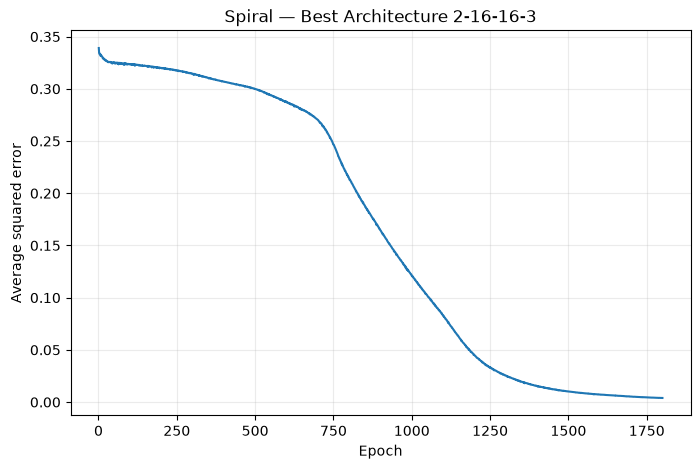

In [33]:
# Required: average error vs epochs ONLY for the selected best architecture.
best_spiral_history = None

for hidden, history in spiral_histories:
    if hidden == best_spiral_hidden:
        best_spiral_history = history
        break

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(best_spiral_history) + 1), best_spiral_history)
plt.xlabel("Epoch")
plt.ylabel("Average squared error")
plt.title(f"Spiral — Best Architecture 2-{best_spiral_hidden[0]}-{best_spiral_hidden[1]}-3")
plt.grid(alpha=0.25)
plt.show()


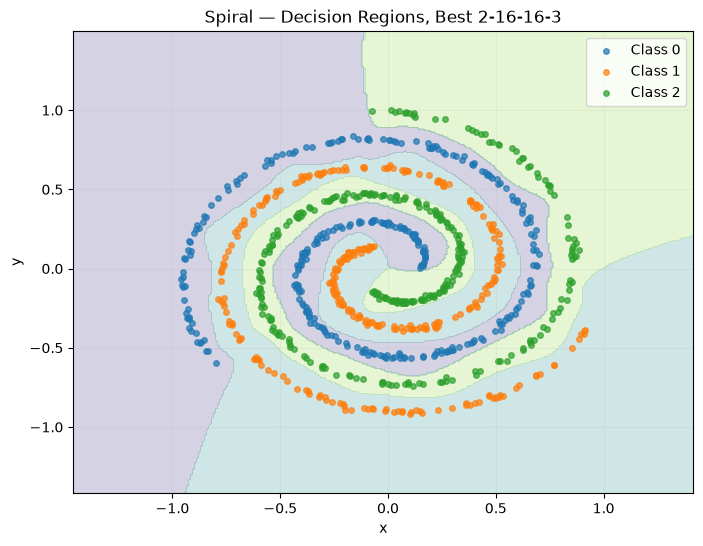

In [34]:
plot_decision_regions(
    best_spiral_model,
    s_train_X,
    s_train_y,
    s_scaler,
    f"Spiral — Decision Regions, Best 2-{best_spiral_hidden[0]}-{best_spiral_hidden[1]}-3"
)


# 10. Required 3-D plots of hidden/output node outputs

For the **best architecture** of each dataset, the assignment asks for plots for:
- every hidden node,
- every output node,
- training data,
- validation data,
- test data.

For each node, the axes are:
- x-axis = first input variable,
- y-axis = second input variable,
- z-axis = output/activation of that node.

The helper below creates one 3-D surface/scatter-style plot per node and split.


Gaussian 3-D node-output plots:


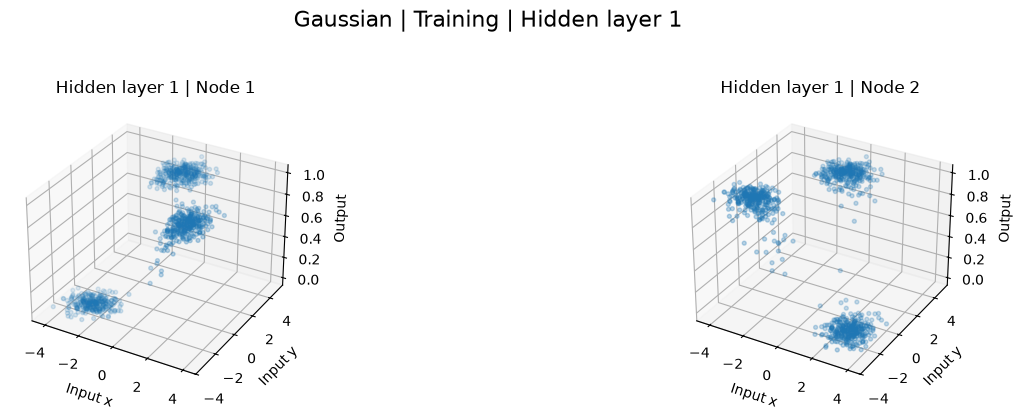

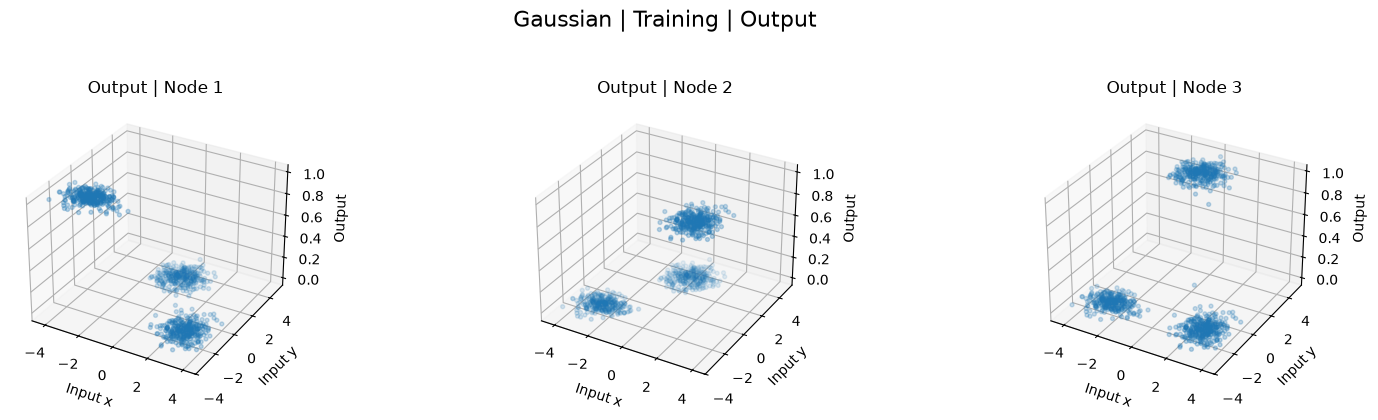

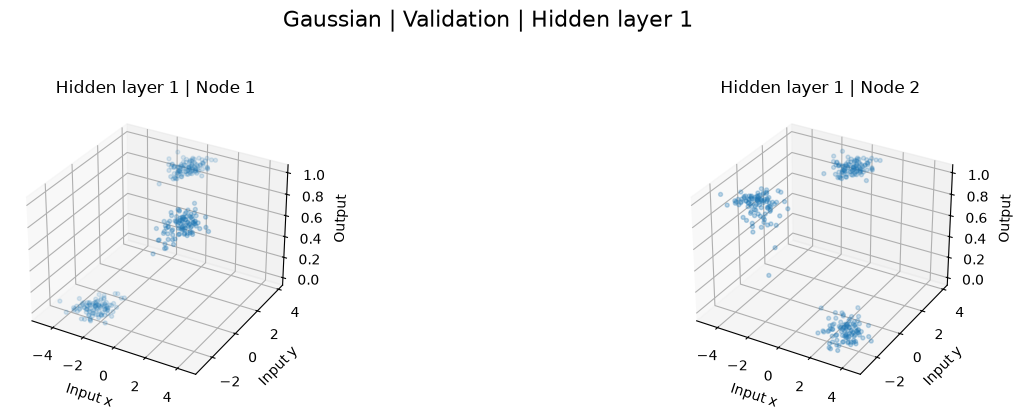

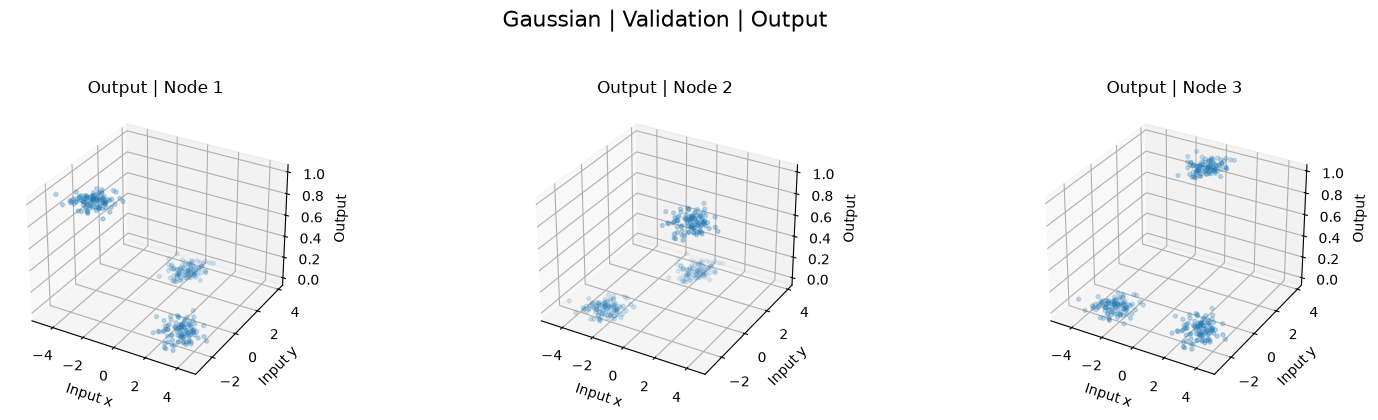

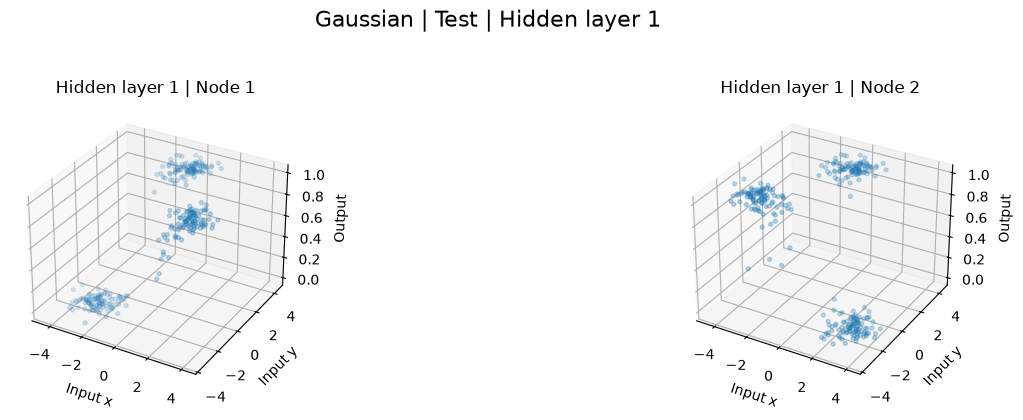

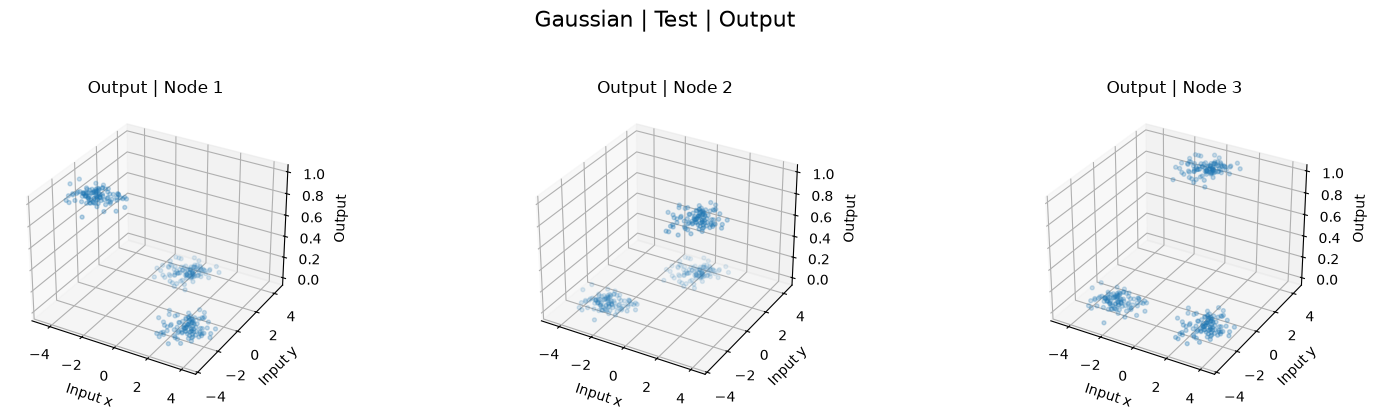

In [53]:
def get_layer_outputs(model, X):
    layer_outputs = [[] for _ in range(len(model.W))]

    for x in X:
        activations, _ = model.forward(x)
        for layer in range(len(model.W)):
            layer_outputs[layer].append(activations[layer + 1].ravel())

    return [np.vstack(values) for values in layer_outputs]


def plot_node_outputs(model, X_original, X_scaled, split_name, dataset_name):
    layer_outputs = get_layer_outputs(model, X_scaled)

    for layer_idx, outputs in enumerate(layer_outputs):

        layer_name = (
            "Output"
            if layer_idx == len(layer_outputs) - 1
            else f"Hidden layer {layer_idx + 1}"
        )

        n_nodes = outputs.shape[1]

        # Arrange nodes in a compact grid
        n_cols = min(4, n_nodes)
        n_rows = int(np.ceil(n_nodes / n_cols))

        fig = plt.figure(figsize=(16, 4 * n_rows))

        for node_idx in range(n_nodes):

            ax = fig.add_subplot(
                n_rows, n_cols, node_idx + 1,
                projection="3d"
            )

            ax.scatter(
                X_original[:, 0],
                X_original[:, 1],
                outputs[:, node_idx],
                s=8,
                alpha=0.55
            )

            ax.set_xlabel("Input x")
            ax.set_ylabel("Input y")
            ax.set_zlabel("Output")

            ax.set_title(
                f"{layer_name} | Node {node_idx + 1}"
            )

        # Overall title
        fig.suptitle(
            f"{dataset_name} | {split_name} | {layer_name}",
            fontsize=16,
            y=0.995
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


print("Gaussian 3-D node-output plots:")
plot_node_outputs(
    best_gaussian_model,
    g_train_X, g_train,
    "Training", "Gaussian"
)
plot_node_outputs(
    best_gaussian_model,
    g_val_X, g_val,
    "Validation", "Gaussian"
)
plot_node_outputs(
    best_gaussian_model,
    g_test_X, g_test,
    "Test", "Gaussian"
)


Spiral 3-D node-output plots:


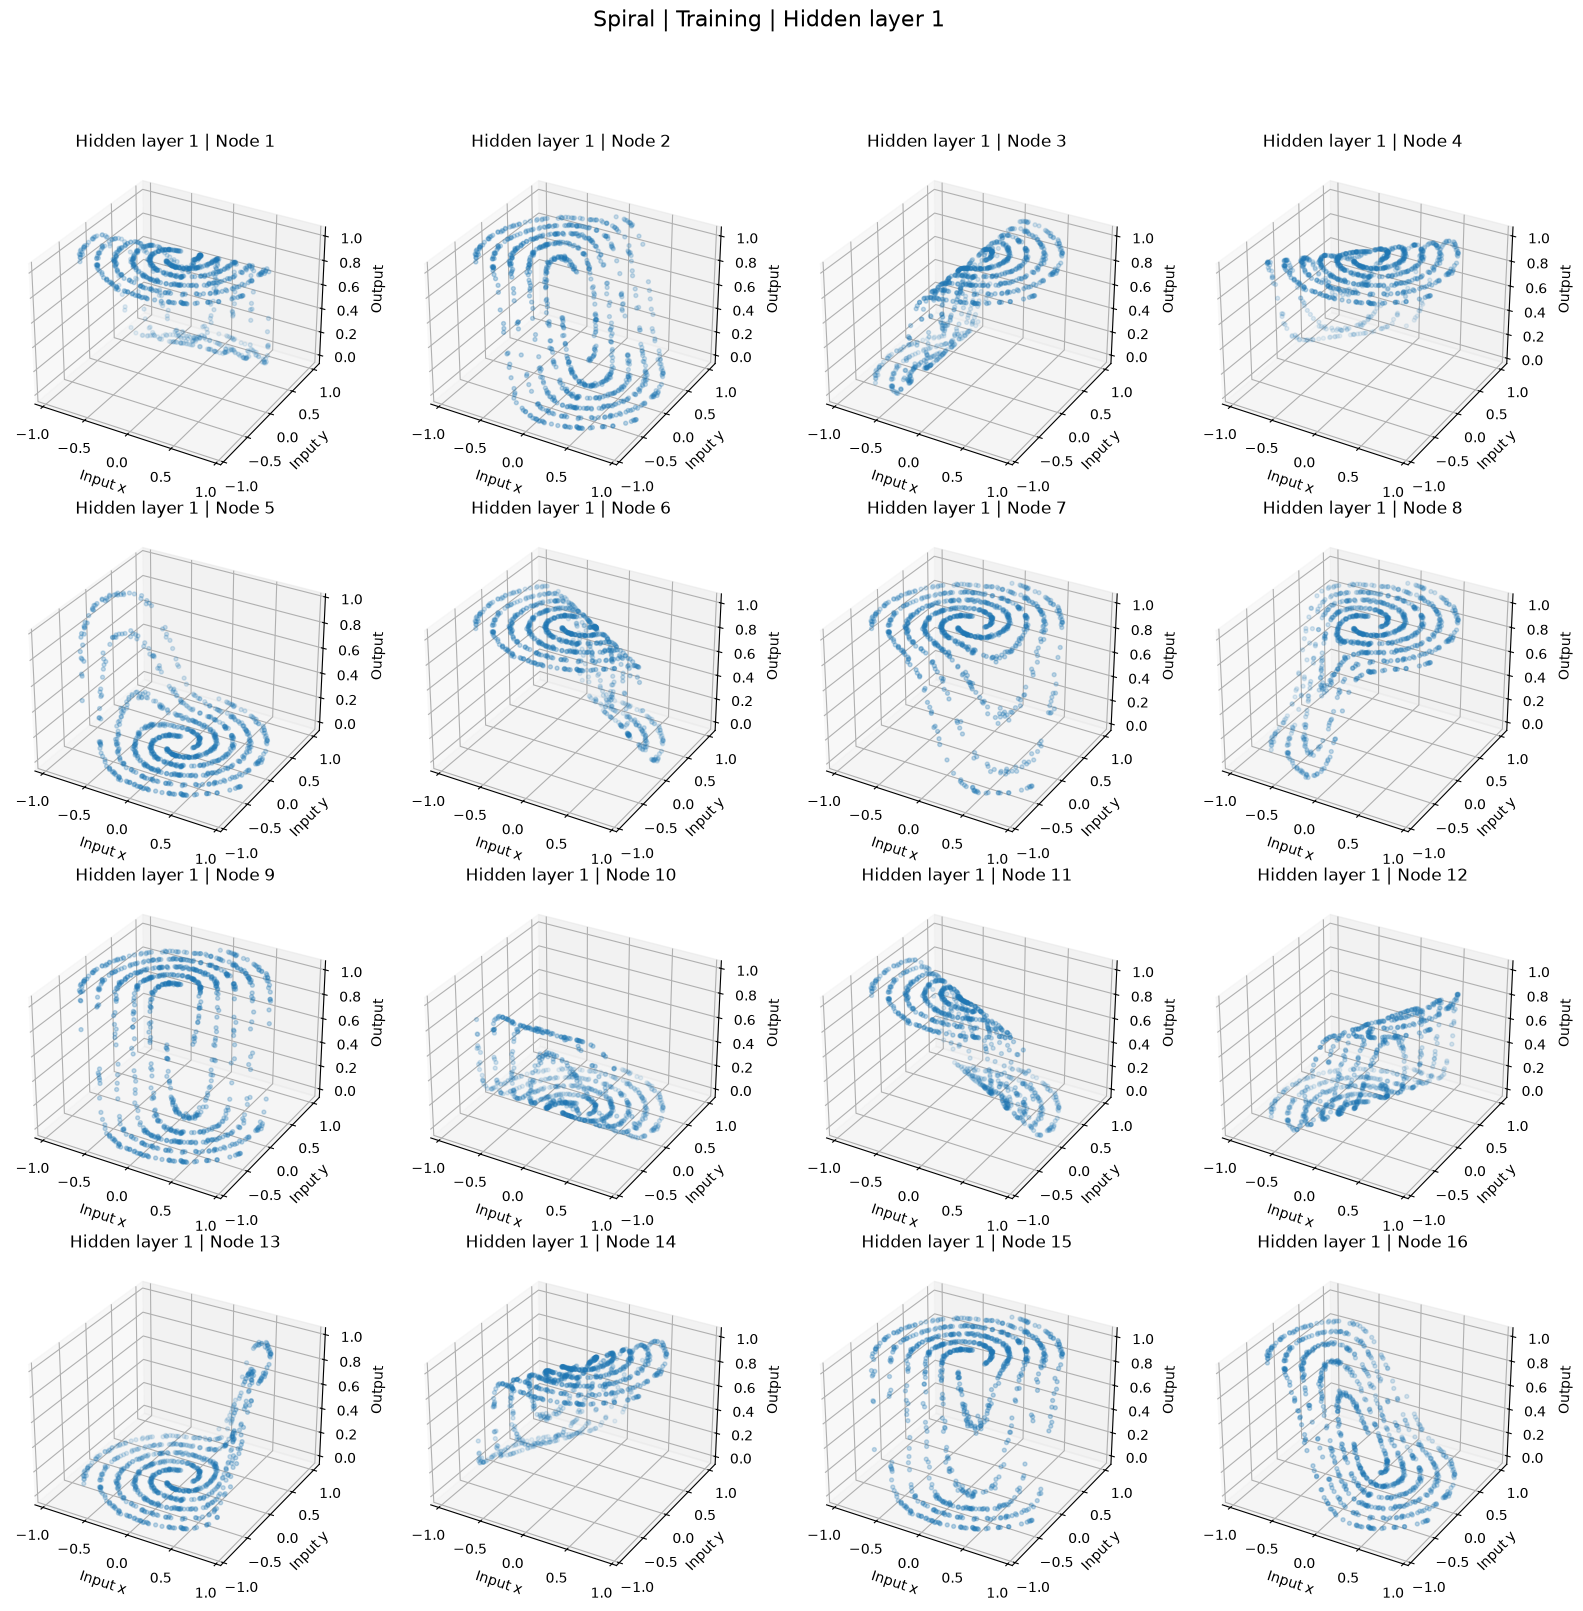

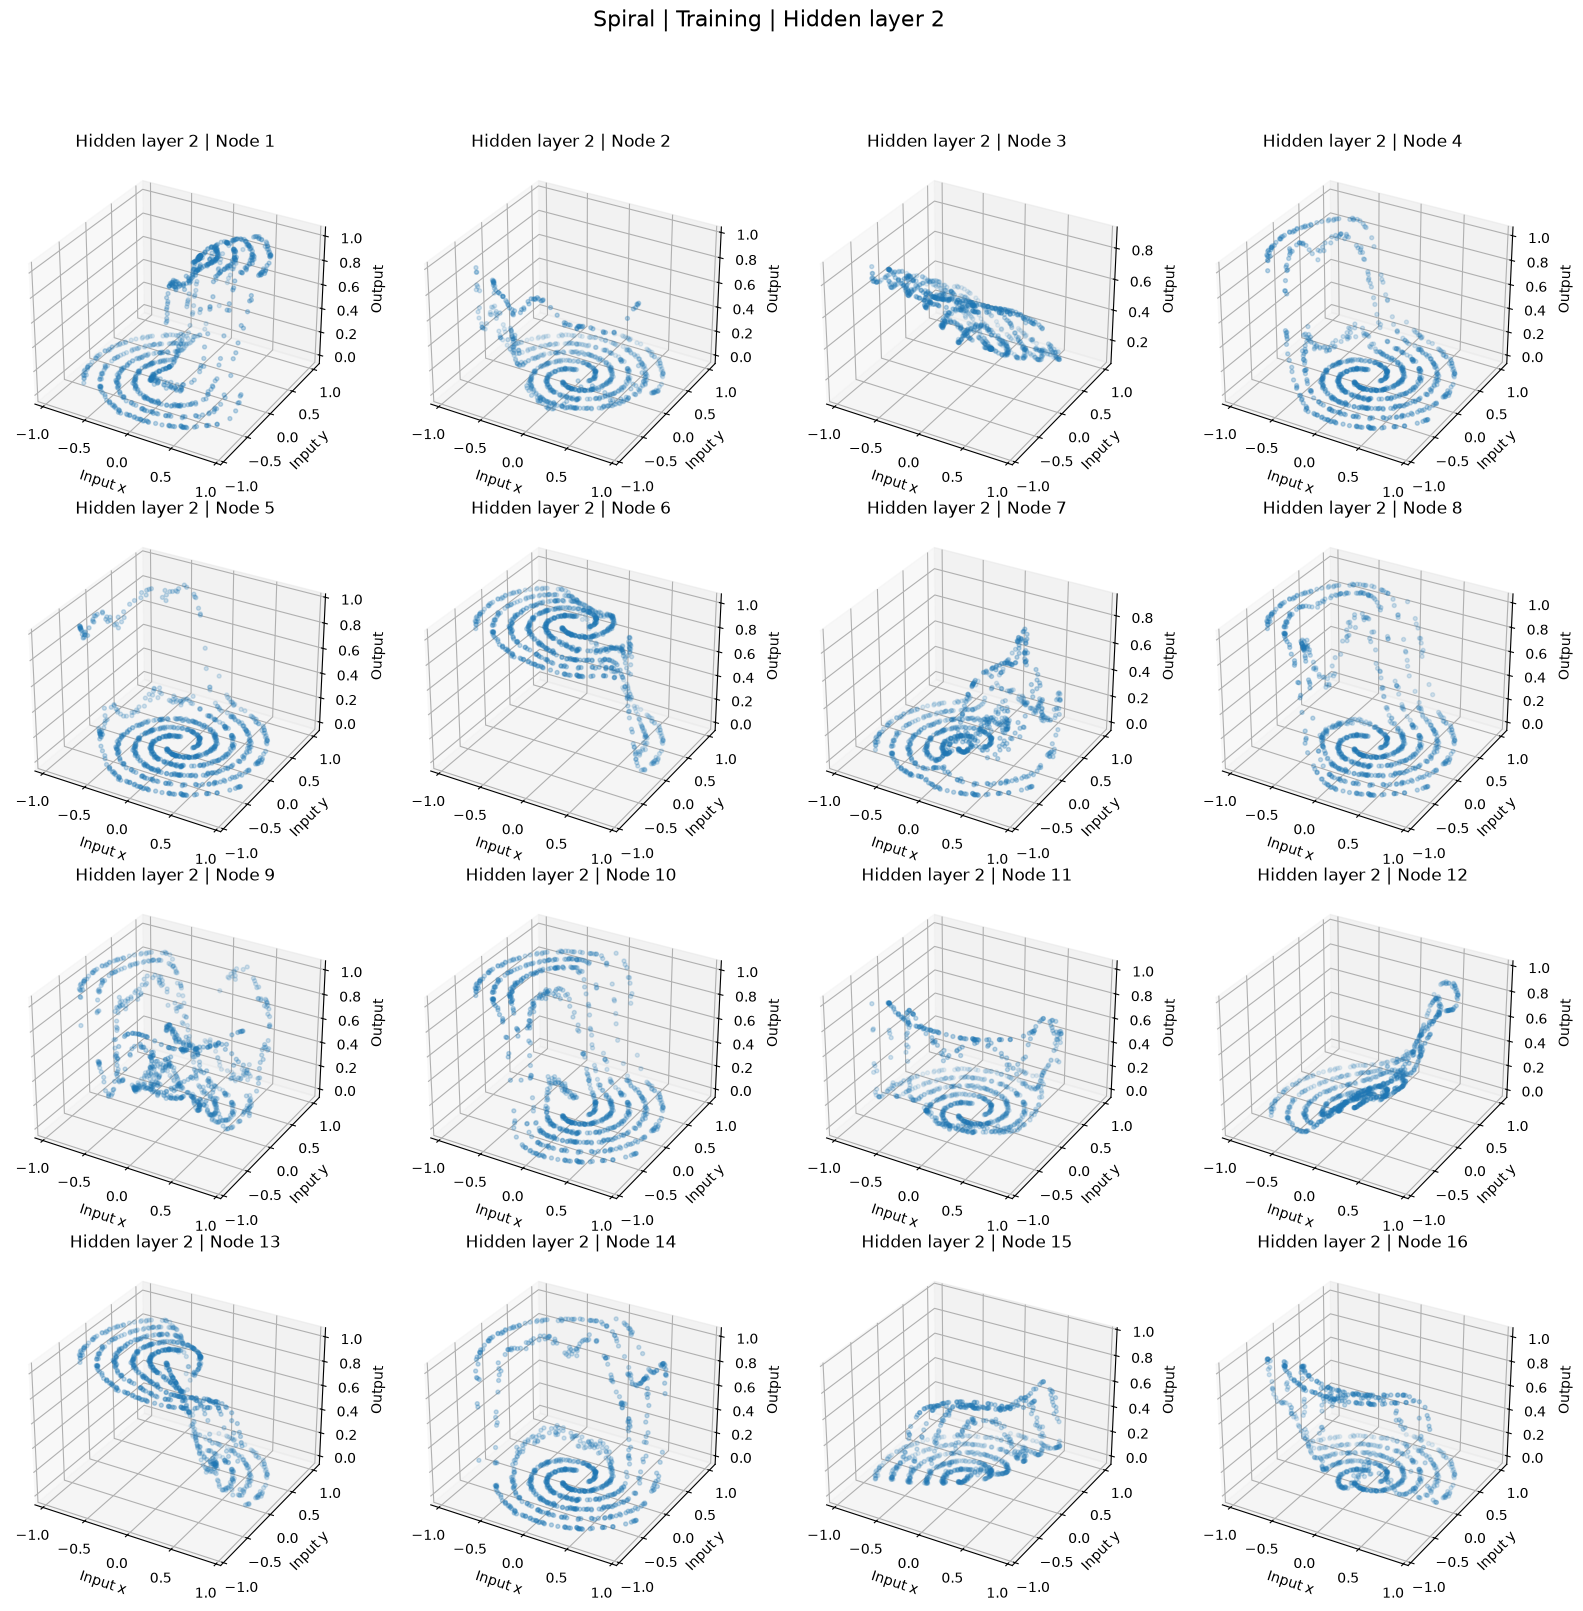

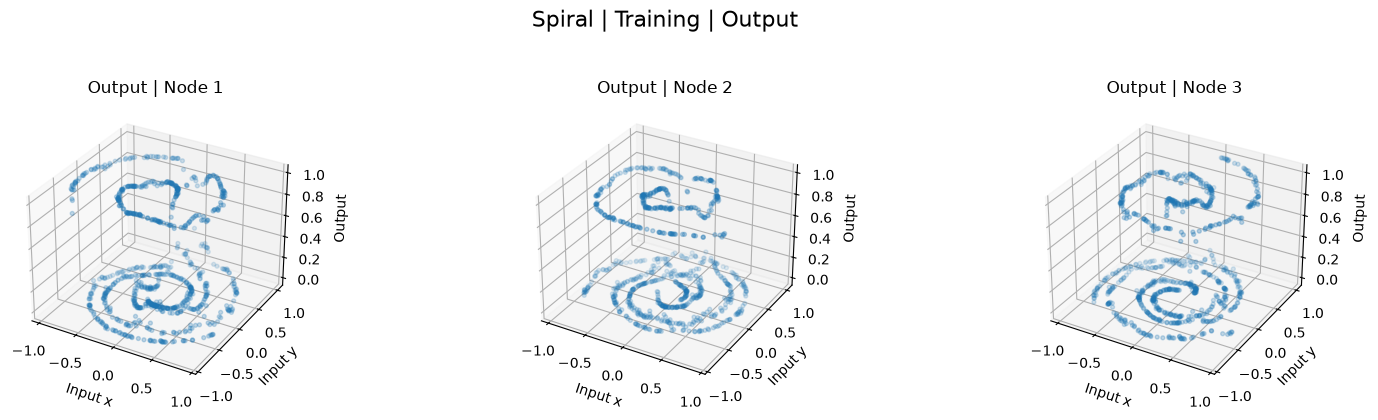

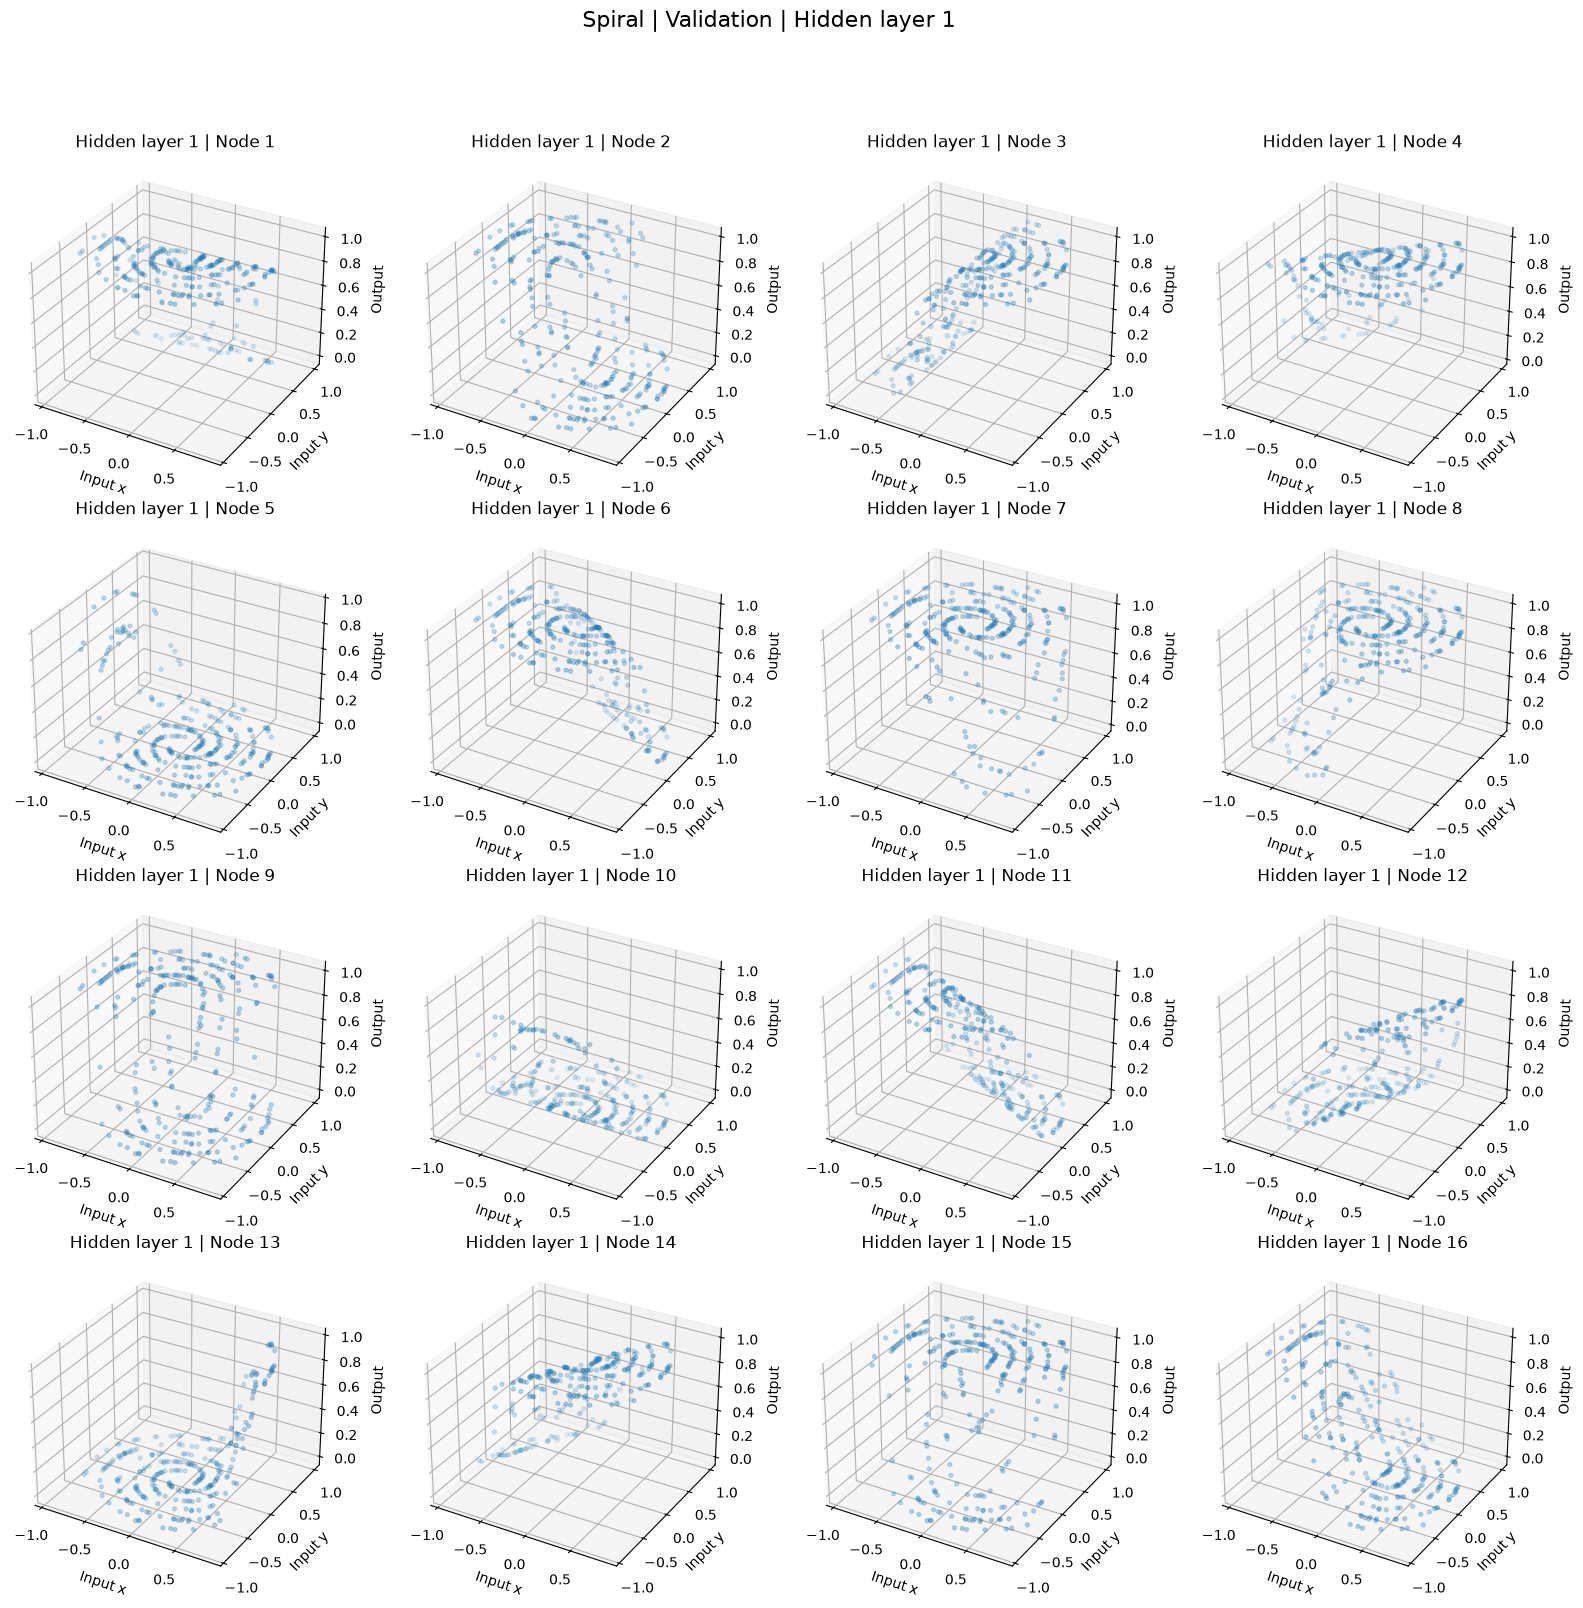

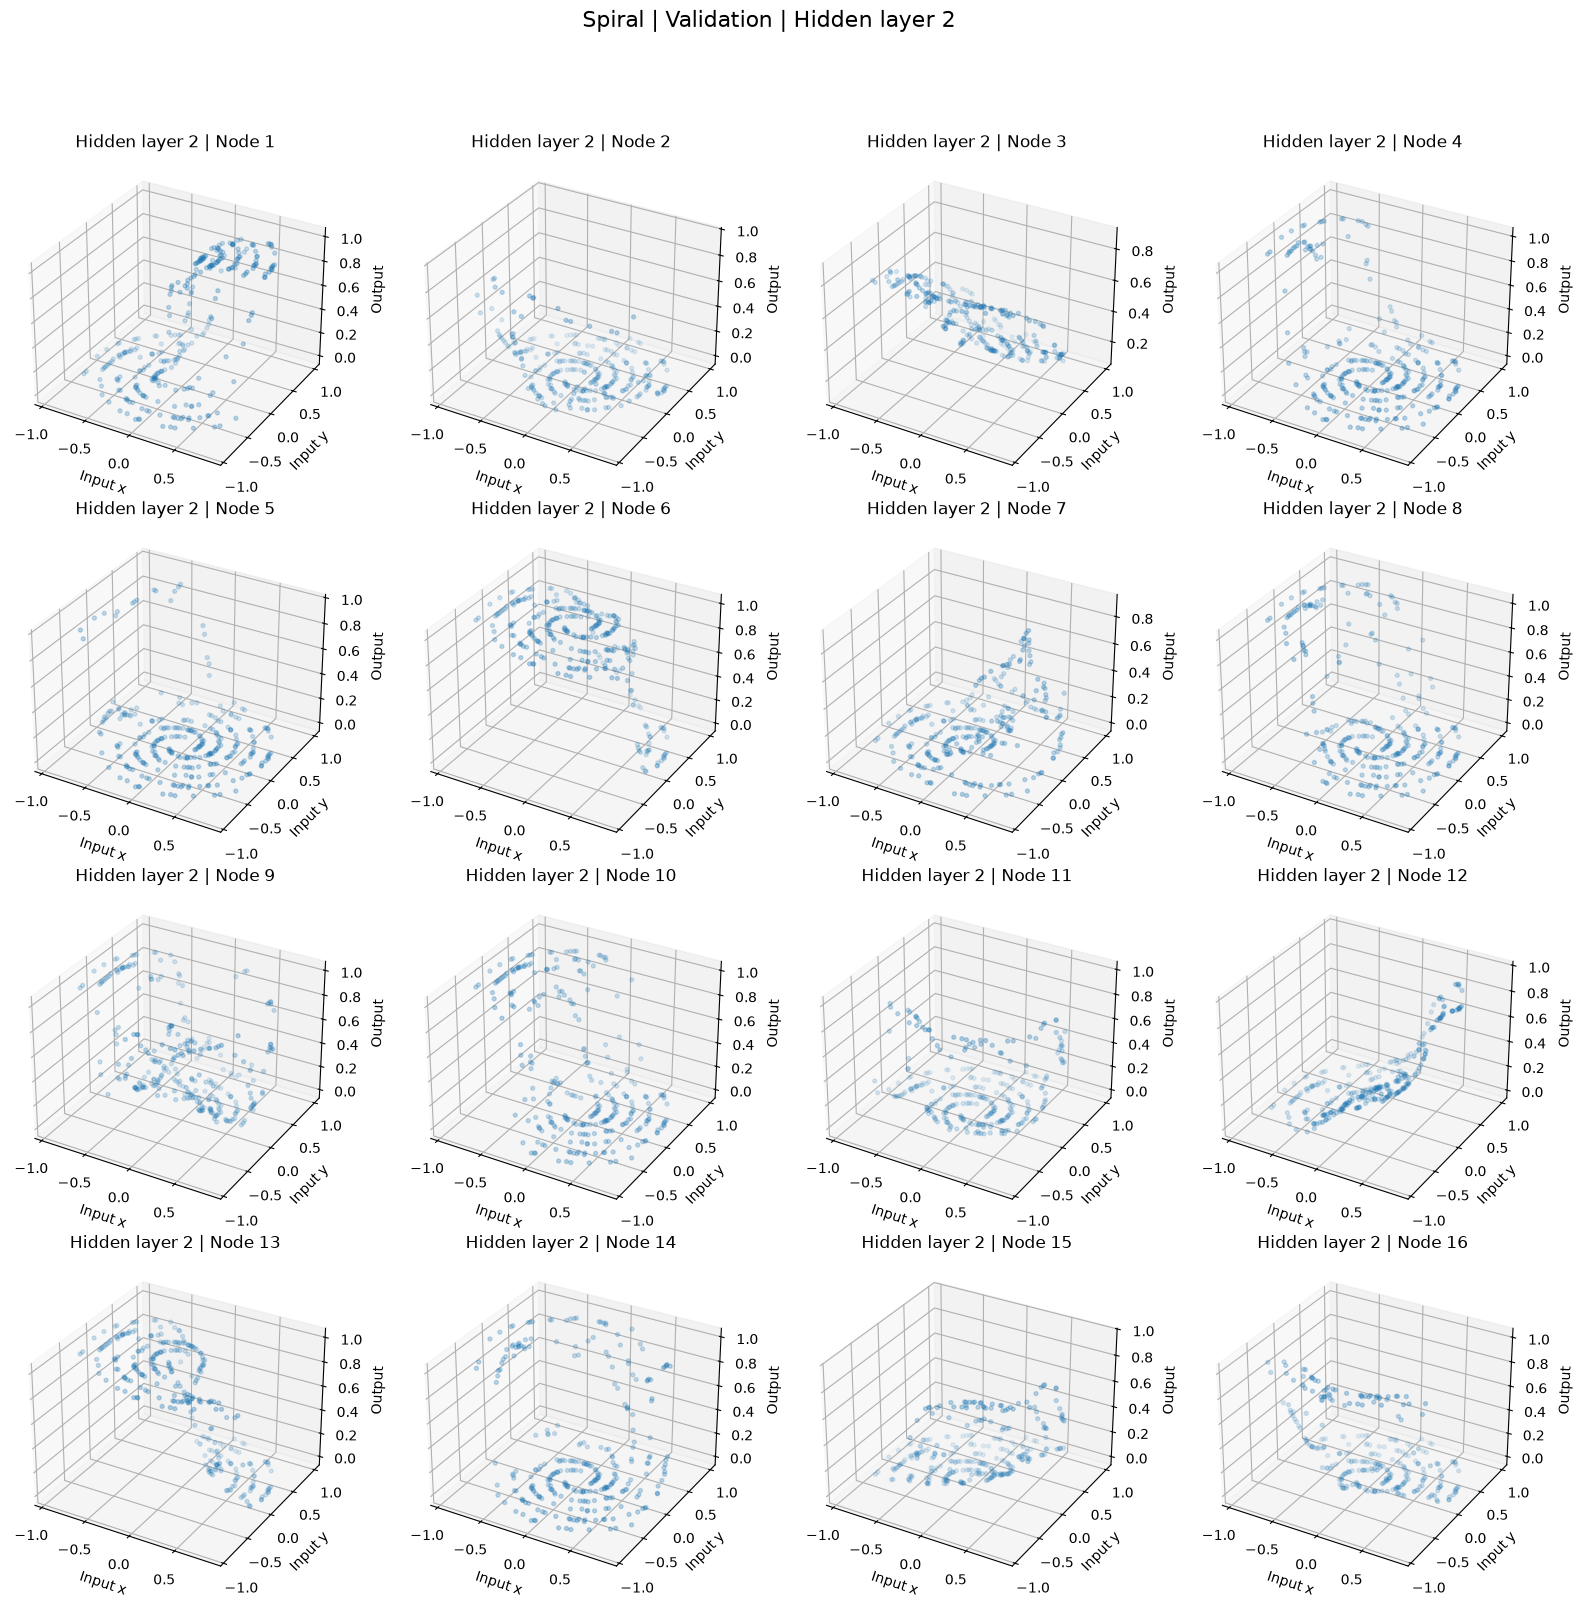

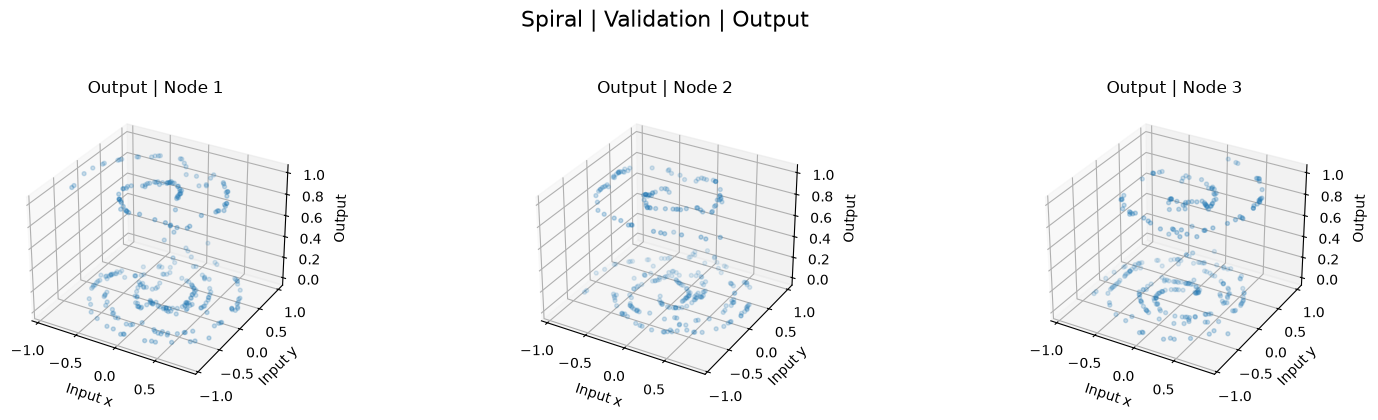

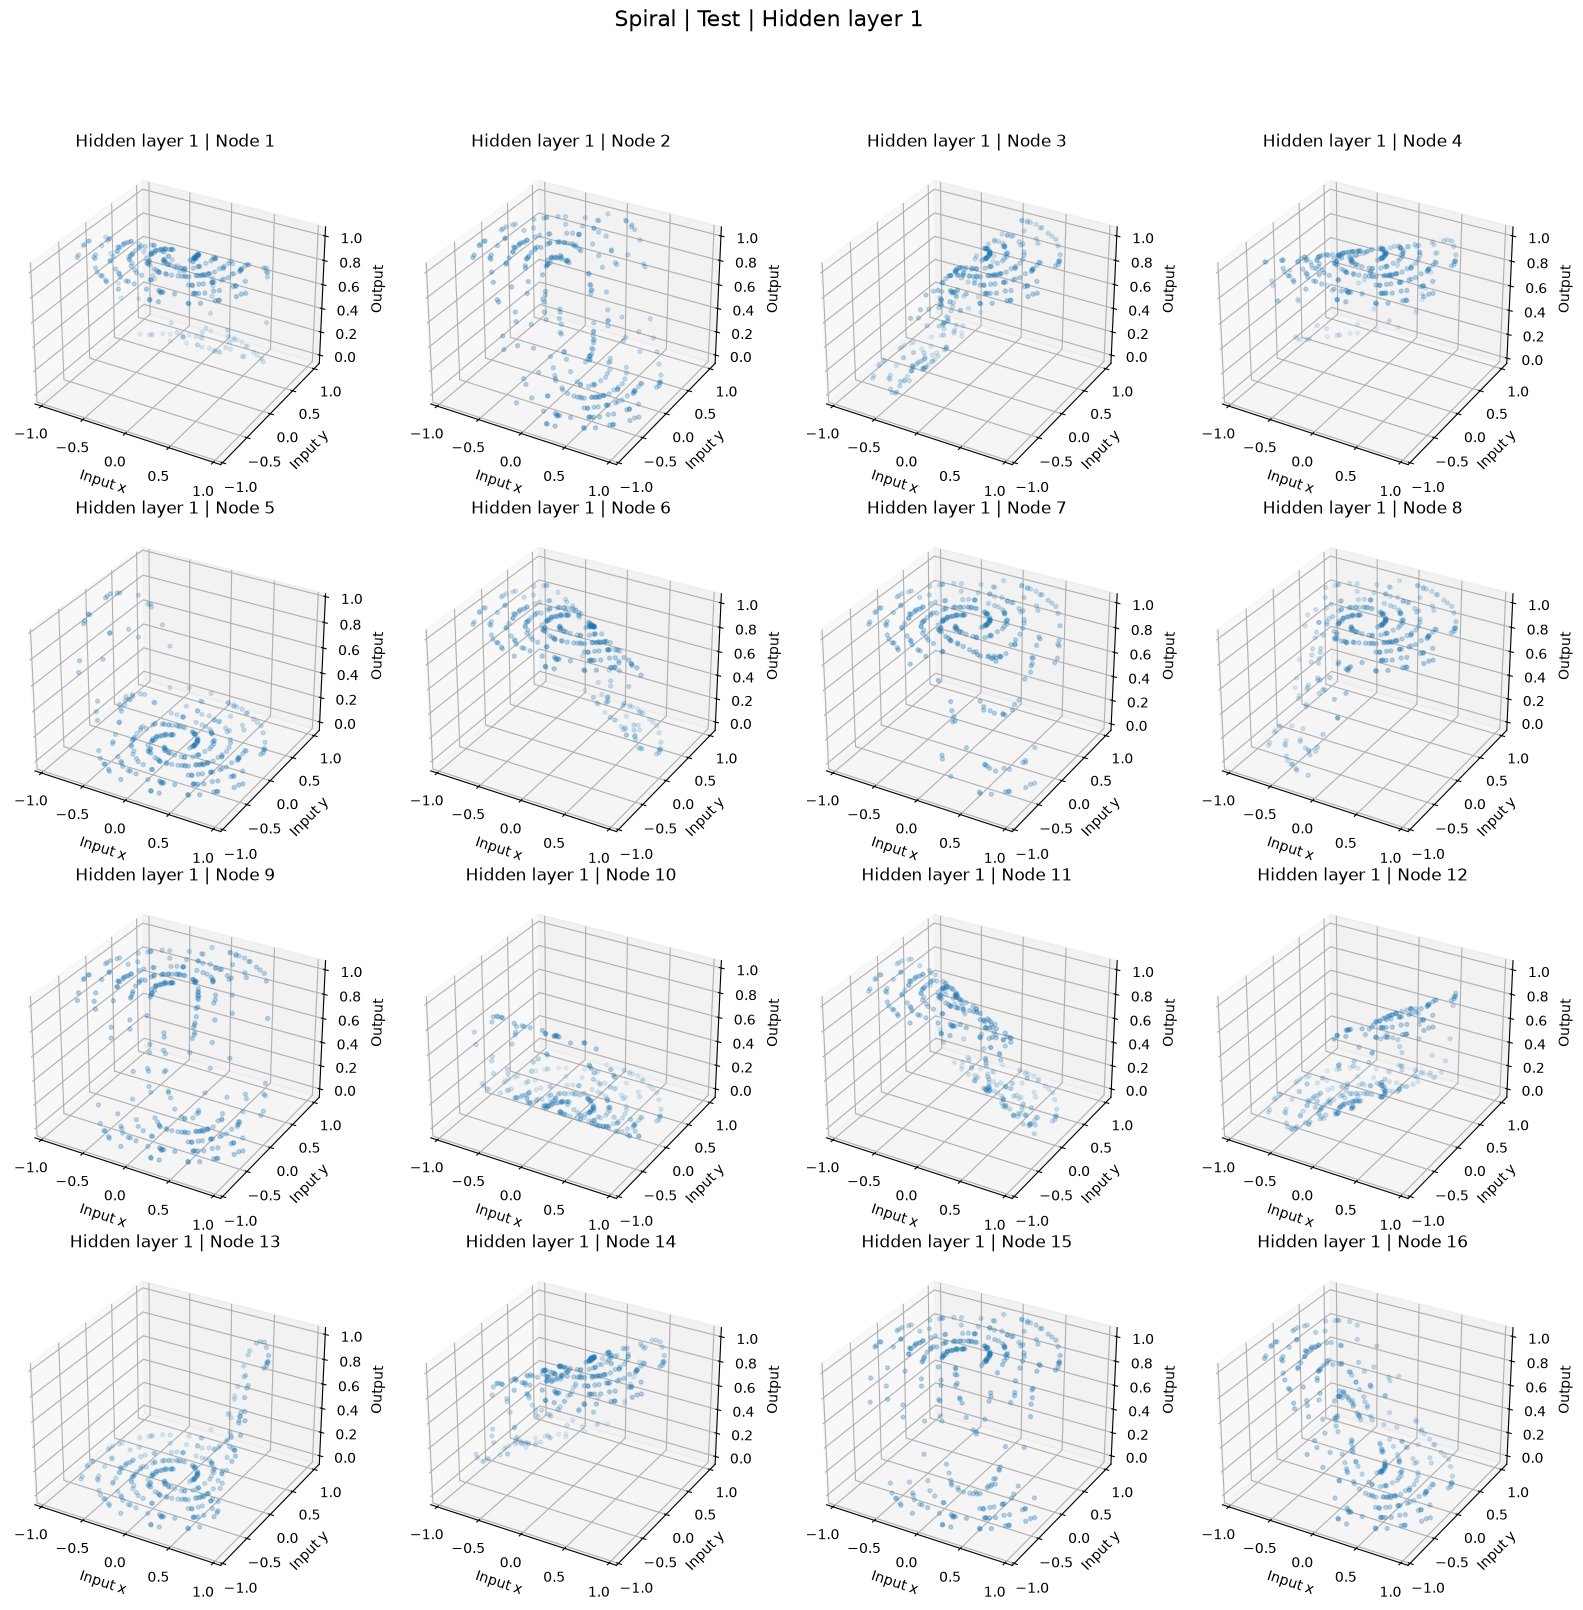

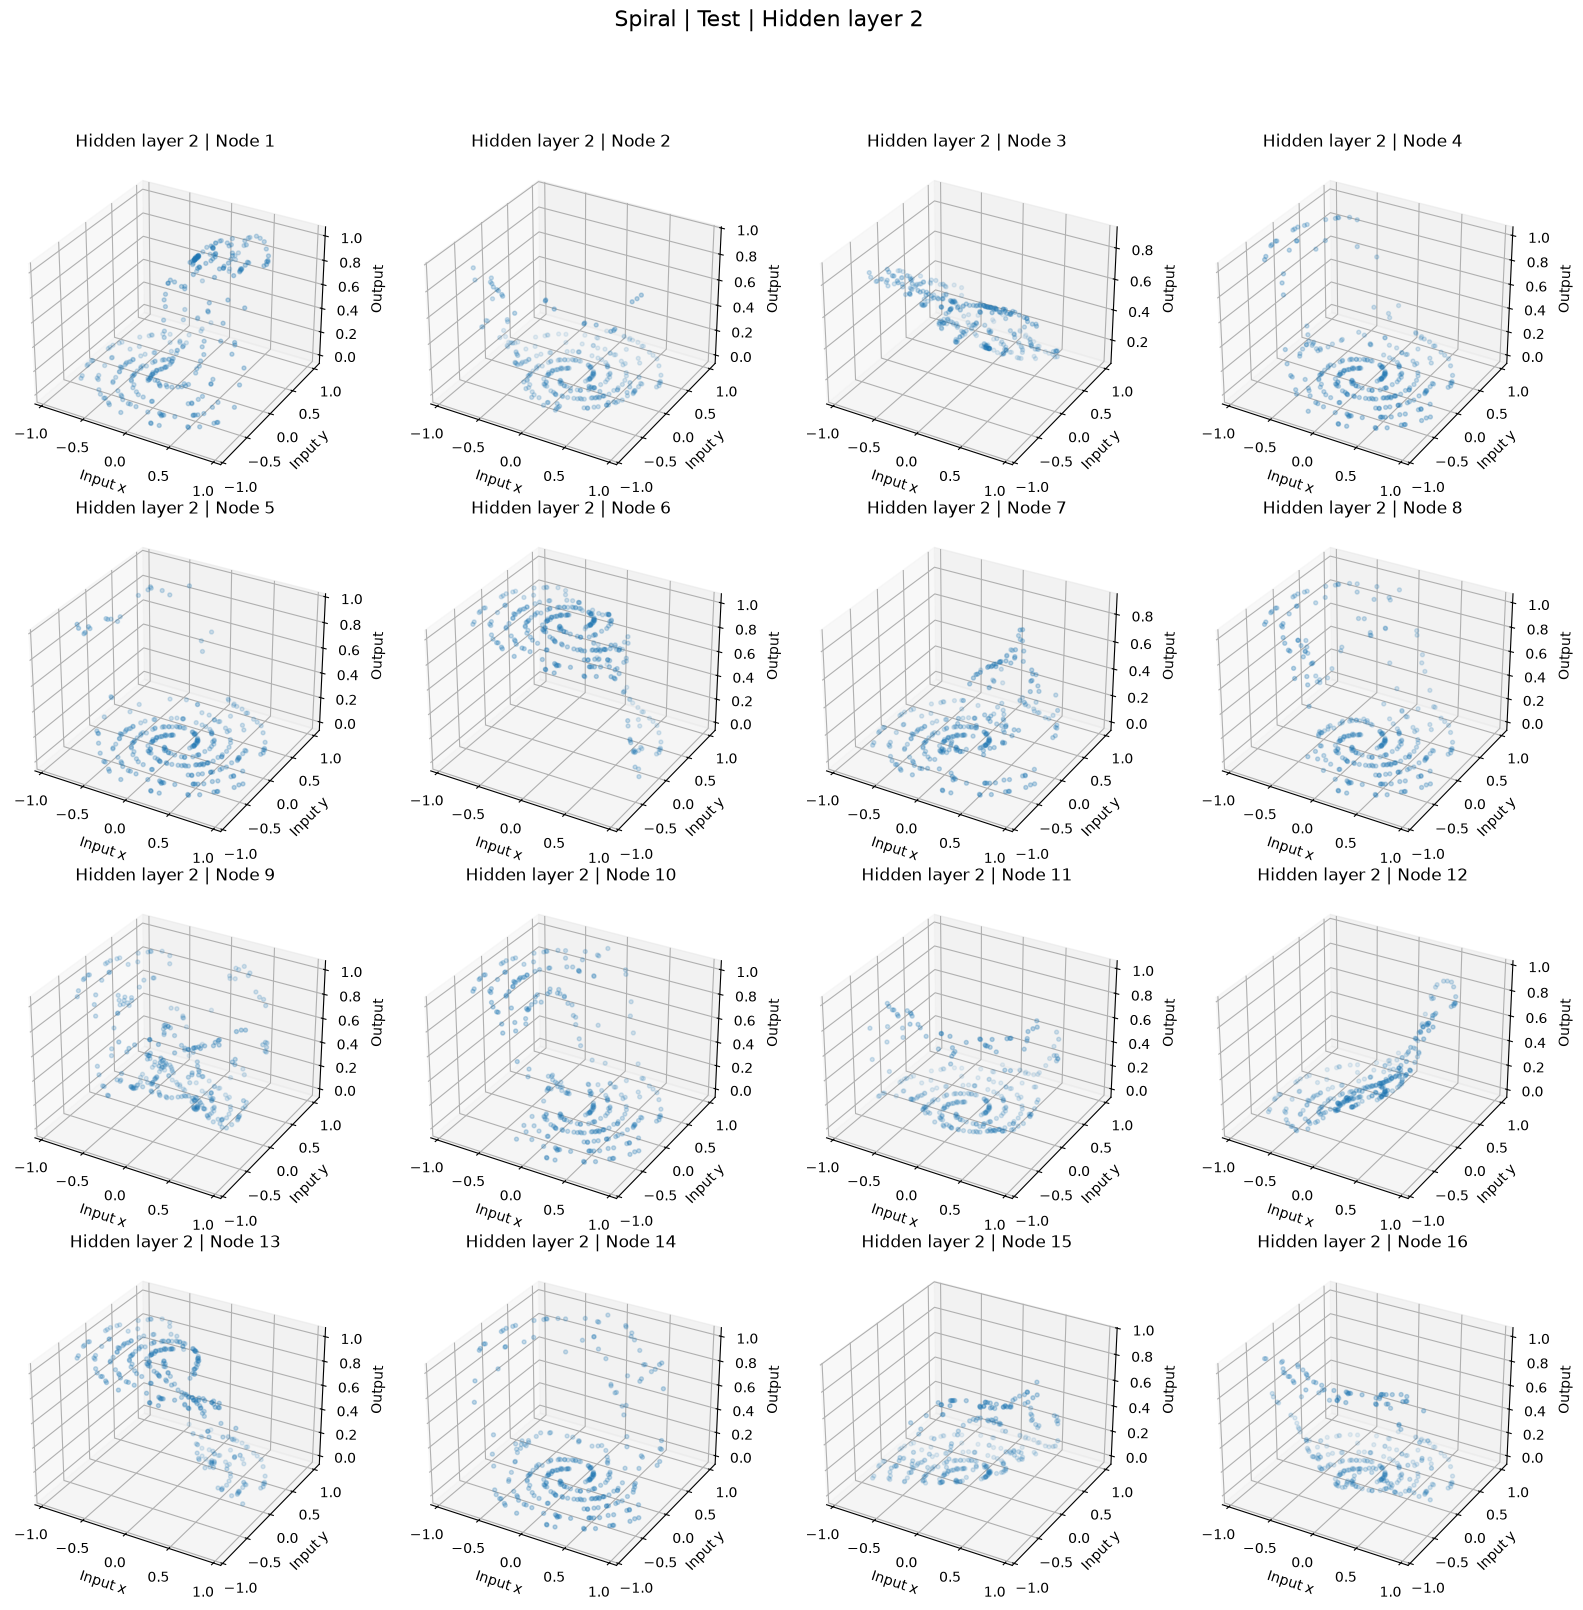

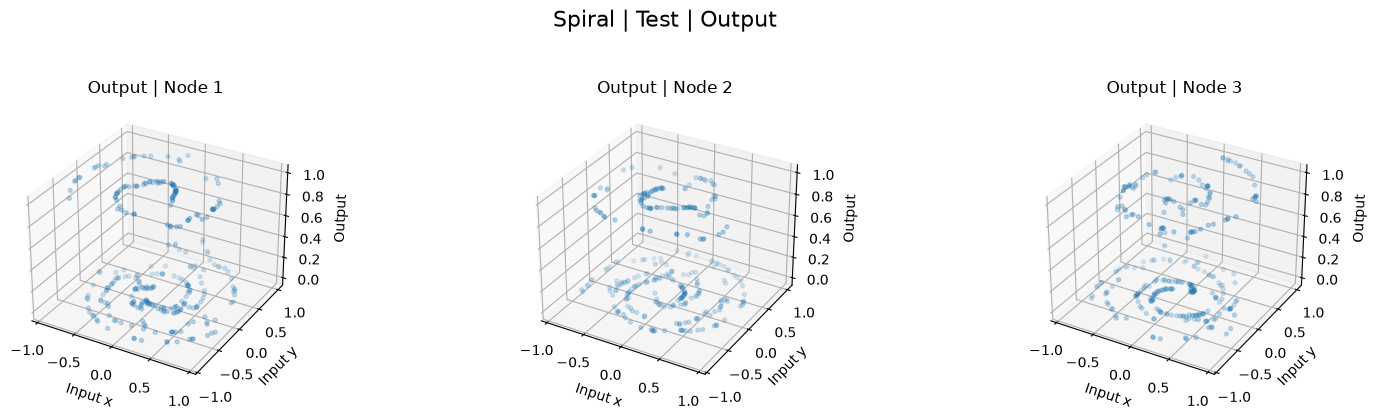

In [54]:
print("Spiral 3-D node-output plots:")
plot_node_outputs(
    best_spiral_model,
    s_train_X, s_train,
    "Training", "Spiral"
)
plot_node_outputs(
    best_spiral_model,
    s_val_X, s_val,
    "Validation", "Spiral"
)
plot_node_outputs(
    best_spiral_model,
    s_test_X, s_test,
    "Test", "Spiral"
)


# 11. Single-neuron baseline

This provides a transparent baseline: a **single linear multiclass neuron layer** trained using the same one-hot targets and SGD squared error. It cannot create nonlinear decision boundaries.

This baseline is especially useful for demonstrating why the spiral dataset needs hidden layers.


In [37]:
class SingleNeuronMulticlass:
    def __init__(self, input_dim, output_dim=3, seed=42, learning_rate=0.03):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.1, size=(input_dim, output_dim))
        self.b = np.zeros((1, output_dim))
        self.learning_rate = learning_rate
        self.rng = np.random.default_rng(seed)

    def forward(self, x):
        return x.reshape(1, -1) @ self.W + self.b

    def predict_scores(self, X):
        return np.vstack([self.forward(x) for x in X])

    def predict(self, X):
        return np.argmax(self.predict_scores(X), axis=1)

    def fit(self, X, Y, epochs=1200):
        history = []

        for epoch in range(epochs):
            idxs = np.arange(len(X))
            self.rng.shuffle(idxs)
            total = 0.0

            for idx in idxs:
                x = X[idx].reshape(1, -1)
                target = Y[idx].reshape(1, -1)

                output = self.forward(x)
                error = output - target
                total += 0.5 * np.sum(error ** 2)

                self.W -= self.learning_rate * (x.T @ error)
                self.b -= self.learning_rate * error

            history.append(total / len(X))

        return np.array(history)


single_gaussian = SingleNeuronMulticlass(2, 3, seed=SEED, learning_rate=0.01)
single_gaussian.fit(g_train, g_train_Y, epochs=GAUSSIAN_EPOCHS)

single_spiral = SingleNeuronMulticlass(2, 3, seed=SEED, learning_rate=0.01)
single_spiral.fit(s_train, s_train_Y, epochs=SPIRAL_EPOCHS)

sg_train_acc, _ = evaluate_model(single_gaussian, g_train, g_train_y)
sg_val_acc, _ = evaluate_model(single_gaussian, g_val, g_val_y)
sg_test_acc, _ = evaluate_model(single_gaussian, g_test, g_test_y)

ss_train_acc, _ = evaluate_model(single_spiral, s_train, s_train_y)
ss_val_acc, _ = evaluate_model(single_spiral, s_val, s_val_y)
ss_test_acc, _ = evaluate_model(single_spiral, s_test, s_test_y)

comparison_df = pd.DataFrame([
    ["Gaussian", "Single linear neuron", sg_train_acc, sg_val_acc, sg_test_acc],
    ["Gaussian", f"Best FCNN {best_gaussian_hidden}", 
     evaluate_model(best_gaussian_model, g_train, g_train_y)[0],
     best_gaussian_val_acc, best_gaussian_test_acc],
    ["Spiral", "Single linear neuron", ss_train_acc, ss_val_acc, ss_test_acc],
    ["Spiral", f"Best FCNN {best_spiral_hidden}",
     evaluate_model(best_spiral_model, s_train, s_train_y)[0],
     best_spiral_val_acc, best_spiral_test_acc]
], columns=["Dataset", "Model", "Training accuracy", "Validation accuracy", "Test accuracy"])

display(comparison_df)


,Dataset,Model,Training accuracy,Validation accuracy,Test accuracy
0,Gaussian,Single linear neuron,1.000000,1.000000,1.000000
1,Gaussian,Best FCNN [2],1.000000,1.000000,1.000000
2,Spiral,Single linear neuron,0.397778,0.440000,0.383333
3,Spiral,"Best FCNN [16, 16]",1.000000,0.996667,0.993333


# 12. Final comparison and automatic observations



In [38]:
final_summary = pd.DataFrame([
    {
        "Dataset": "Gaussian",
        "Best architecture": f"2-{best_gaussian_hidden[0]}-3",
        "Validation accuracy": best_gaussian_val_acc,
        "Test accuracy": best_gaussian_test_acc
    },
    {
        "Dataset": "Spiral",
        "Best architecture": f"2-{best_spiral_hidden[0]}-{best_spiral_hidden[1]}-3",
        "Validation accuracy": best_spiral_val_acc,
        "Test accuracy": best_spiral_test_acc
    }
])

display(final_summary)

print("\nKey observations:")
print(f"1. Gaussian best architecture: 2-{best_gaussian_hidden[0]}-3.")
print(f"   Validation accuracy = {best_gaussian_val_acc:.4f}; Test accuracy = {best_gaussian_test_acc:.4f}.")
print(f"2. Spiral best architecture: 2-{best_spiral_hidden[0]}-{best_spiral_hidden[1]}-3.")
print(f"   Validation accuracy = {best_spiral_val_acc:.4f}; Test accuracy = {best_spiral_test_acc:.4f}.")
print("3. The Gaussian dataset is linearly separable, so even a simple model can perform strongly.")
print("4. The spiral dataset requires nonlinear transformations; hidden layers allow the network to create nonlinear decision regions.")
print("5. Increasing hidden nodes can improve representational capacity, but more nodes do not automatically guarantee better validation performance.")
print("6. Validation accuracy is used for architecture selection; the test set is reserved for final evaluation of the selected architecture.")


,Dataset,Best architecture,Validation accuracy,Test accuracy
0,Gaussian,2-2-3,1.000000,1.000000
1,Spiral,2-16-16-3,0.996667,0.993333



Key observations:
1. Gaussian best architecture: 2-2-3.
   Validation accuracy = 1.0000; Test accuracy = 1.0000.
2. Spiral best architecture: 2-16-16-3.
   Validation accuracy = 0.9967; Test accuracy = 0.9933.
3. The Gaussian dataset is linearly separable, so even a simple model can perform strongly.
4. The spiral dataset requires nonlinear transformations; hidden layers allow the network to create nonlinear decision regions.
5. Increasing hidden nodes can improve representational capacity, but more nodes do not automatically guarantee better validation performance.
6. Validation accuracy is used for architecture selection; the test set is reserved for final evaluation of the selected architecture.
